In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/mSHIFT_SHeS/code_ocean/

/content/drive/MyDrive/mSHIFT_SHeS/code_ocean


This notebooks contains the steps to compute the nutrient content, environmental impact and cost per gram of all meat and dairy substitute food items. In addition, this notebook computes the weighted composite items that replace the meat and dairy items in the substitution simulations.  

In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path
import sys

data_path = Path("data")

In [ ]:
# Add the parent directory of the notebook to sys.path, enables module imports from notebook_code
sys.path.append(str(Path().resolve() / 'code/notebooks/notebook_code'))

In [ ]:
# Set the plot formatting
plt.rcParams["font.family"] = 'serif'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.formatter.use_mathtext"] = True

In [ ]:
from substitution_processing import item_only_nutrients, weighted_consumption, daily_consumption_dict, unique_mixed_items, add_weighted_composite

In [ ]:
diet_data = pd.read_parquet(data_path / "diet_data.parquet")

In [ ]:
nutrients = np.loadtxt(data_path / 'indicator_lists/nutrients.txt', dtype=str).tolist()
env_columns = np.loadtxt(data_path / 'indicator_lists/env_columns.txt', dtype=str).tolist()
error_columns = np.loadtxt(data_path / 'indicator_lists/error_columns.txt', dtype=str).tolist()
all_indicators = nutrients + env_columns

In [ ]:
# Specify directory to save the plots of the contribution of food items to substitute
plot_path = Path("results/Plots/substitutes")

In [ ]:
df_baseline = pd.read_parquet(data_path / "df_baseline.parquet")

In [ ]:
RRPM_food_groups = ['Beefg',
 'Lambg',
 'Porkg',
 'Burgersg',
 'OtherRedMeatg',
 'ProcessedRedMeatg',
 'Sausagesg',
 'Offalg']

dairy_food_groups = ['Milk_Skimmed',
 'Milk_SemiSkimmed',
 'Milk_Whole',
 'Cheese_Skimmed',
 'Cheese_SemiSkimmed',
 'Cheese_Whole',
 'Yogurt_Skimmed',
 'Yogurt_SemiSkimmed',
 'Yogurt_Whole',
 'Cream_SemiSkimmed',
 'Cream_Whole',
 'Butter']

In [ ]:
nutrients_per_gram_dairy = pd.read_parquet(data_path / "nutrients_per_gram_dairy.parquet")

In [ ]:
ndb_data_path = data_path / 'NDB_data/NDB_intake24-nutrient-mapping-UK_V2_2022-18-10-2022.csv'
ndb_data = pd.read_csv(ndb_data_path)

In [ ]:
recipe_data = pd.read_excel(data_path / 'dairy_disag/NDB_SHeS_Disag_Dairy_08012024.xlsx')

# Compute the weights of each item per food group in the weighted composite replacements for each food group

In [ ]:
def calculate_proportion_non_composite(non_composite_list: list, proportional_dict: dict):

  """
  CAlculates the relative proportion of non_composite items to the dictionary of the weighetd contribution of composite and non-composite items
  """

  total_prop = 0
  for item, proportion in proportional_dict.items():
    if item in set(non_composite_list):
      total_prop += proportion

  return total_prop/100

Vegetable substitute

In [ ]:
beans_only, mixed_beans = unique_mixed_items(variable='Beansg', diet_data=diet_data)
brass_only, mixed_brass = unique_mixed_items(variable='Brassicaceaeg', diet_data=diet_data)
yrg_only, mixed_yrg = unique_mixed_items(variable='YellowRedGreeng', diet_data=diet_data)
tomatoes_only, mixed_tomatoes = unique_mixed_items(variable='Tomatoesg', diet_data=diet_data)
otherveg_only, mixed_otherveg = unique_mixed_items(variable='OtherVegg', diet_data=diet_data)

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(beans_only)])

167

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(beans_only)])/len(diet_data)

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(beans_only)])/len(diet_data[diet_data['FoodDescription'].isin(beans_only+mixed_beans)])

0.08246913580246913

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(beans_only)])

167

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(yrg_only+brass_only+tomatoes_only + otherveg_only)])/len(diet_data)

0.055784461276553746

In [ ]:
len(diet_data[diet_data['RecipeSubFoodGroupCode']=='37K'])/len(diet_data)

0.0021382809865699505

In [ ]:
diet_data[diet_data['RecipeSubFoodGroupCode']=='37K']["RecipeSubFoodGroupDesc"].unique()

array(['MEAT ALTERNATIVES INCL READY MEALS & HOMEMADE DISH'], dtype=object)

In [ ]:
veg_items = []
for foods in [brass_only, yrg_only, tomatoes_only, otherveg_only]:
  veg_items += foods

In [ ]:
dict_item_percent = daily_consumption_dict(item_list=veg_items, diet_data=diet_data)
veg_dict_percent_all = {k: v for k, v in dict_item_percent.items()}
top_items_veg_all = sorted(veg_dict_percent.items(), key=lambda x: x[1], reverse=True)

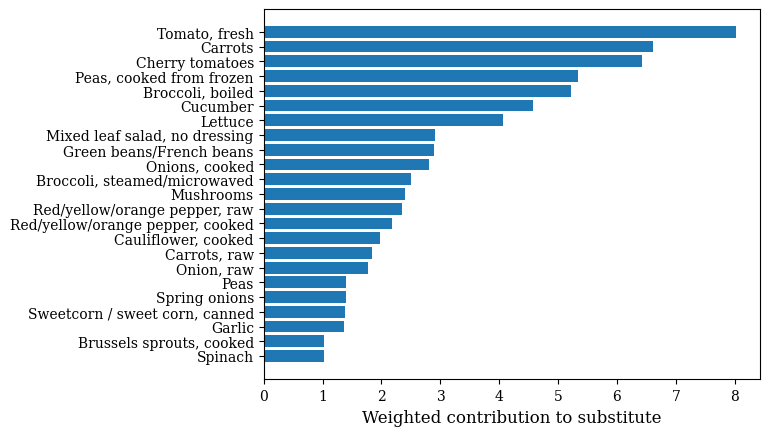

In [ ]:
dict_item_percent = daily_consumption_dict(item_list=veg_items, diet_data=diet_data)
veg_dict_percent = {k: v for k, v in dict_item_percent.items() if v > 1}
top_items_veg = sorted(veg_dict_percent.items(), key=lambda x: x[1], reverse=True)

# Plot a histogram of the top items
labels, values = zip(*top_items_veg)
labels = labels[::-1]
values = values[::-1]
plt.barh(labels, values)
plt.xlabel('Weighted contribution to substitute', fontsize = 12)
plt.savefig(plot_path / "veg_sub.png", dpi=300,bbox_inches="tight")
plt.show()

Plant-based meat alternatives

In [ ]:
# identify items in the PBMA group that also contain dairy
pbma_dairy_items = diet_data[(diet_data['RecipeSubFoodGroupCode']=='37K') & (diet_data[dairy_food_groups].any(axis=1) > 0)]['FoodDescription'].unique()

In [ ]:
!ls ../Data/Dairy\ disag

dairy_disag_16122023.xlsx  NDB_SHeS_Disag_Dairy_08012024.xlsx
diet_data_dairy.parquet    old


In [ ]:
PB_alt = diet_data[diet_data['RecipeSubFoodGroupCode']=='37K']['FoodDescription'].unique().tolist()

In [ ]:
for i in PB_alt:
  if i in pbma_dairy_items:
    print(i)

Vegetarian mince chilli (e.g. Quorn)
Vegetarian chicken-style burger/fillet in breadcrumbs (e.g. Quorn), no bun
Vegetarian sausage roll, meat style (e.g. Quorn)
Vegetarian chicken-style nuggets/goujons, in breadcrumbs (e.g. Quorn nuggets)
Vegetarian meat-style burger (e.g Quorn), no bun
Vegetarian mince lasagne (e.g. Quorn)
Vegetarian meat-free slices (e.g. Quorn chicken/ham-style)
Vegetarian pie, meat-style (e.g. Quorn)
Quorn sausage
Vegetarian Cornish pasty (e.g. Linda McCartney, Quorn)
Vegetarian sausage, cheese based


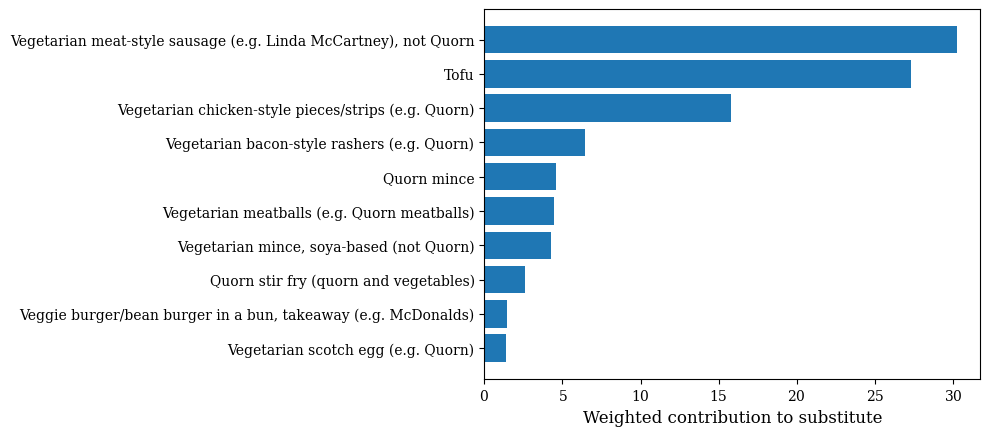

In [ ]:
PB_alt = diet_data[diet_data['RecipeSubFoodGroupCode']=='37K']['FoodDescription'].unique().tolist()

# # Remove the food items in the composite that contain cheese to ensure that the dairy reduction is fixed
# for item in PB_alt:
#   if 'cheese' in item.lower():
#     PB_alt.remove(item)

PB_alt = [item for item in PB_alt if item not in set(pbma_dairy_items)]

PB_dict_percent =  daily_consumption_dict(item_list=PB_alt, diet_data=diet_data)
PB_dict_percent = result = {k: v for k, v in PB_dict_percent.items() if v > 1}
top_items_PB_alt = sorted(PB_dict_percent.items(), key=lambda x: x[1], reverse=False)

labels, values = zip(*top_items_PB_alt)
plt.barh(labels, values)
plt.xlabel('Weighted contribution to substitute', fontsize = 12)
plt.savefig(plot_path / "PB_alt_sub.png", dpi=300,bbox_inches="tight")
plt.show()

Pulses and legumes

In [ ]:
all_meat_food_groups = np.loadtxt(data_path / "indicator_lists/all_meat_food_groups.txt", dtype = str).tolist()

In [ ]:
all_meat_food_groups

['Beefg',
 'Lambg',
 'Porkg',
 'Burgersg',
 'OtherRedMeatg',
 'ProcessedRedMeatg',
 'Sausagesg',
 'Offalg',
 'Poultryg',
 'ProcessedPoultryg',
 'GameBirdsg']

In [ ]:
all_bean_items = beans_only + mixed_beans

In [ ]:
meat_bean_items = diet_data[diet_data["FoodDescription"].isin(all_bean_items) & (diet_data[all_meat_food_groups].any(axis=1) > 0)]['FoodDescription'].unique()
fish_bean_items = diet_data[diet_data["FoodDescription"].isin(all_bean_items) & (diet_data[["WhiteFishg", "OilyFishg", "Shellfishg"]].any(axis=1) > 0)]['FoodDescription'].unique()
dairy_bean_items = diet_data[diet_data["FoodDescription"].isin(all_bean_items) & (diet_data[dairy_food_groups].any(axis=1) > 0)]['FoodDescription'].unique()

In [ ]:
dairy_bean_items

array(['Thai vegetable curry', 'Vegetarian sushi', 'Vegetable burritos',
       'Lentil curry, with tomatoes', 'Lamb biryani',
       'Vegetarian pate (e.g. mushroom)', 'Chicken biryani',
       'Pea and mint soup', 'Vegetable enchiladas', 'Beef biryani',
       'Vegetarian sausage, cheese based'], dtype=object)

In [ ]:
diet_data[diet_data["FoodDescription"]=='Bolognese sauce, made with vegetarian mince (e.g. Quorn)'][["FoodNumber" ,'RecipeSubFoodGroupDesc', 'RecipeSubFoodGroupCode']].head()

,FoodNumber,RecipeSubFoodGroupDesc,RecipeSubFoodGroupCode
10808,9180,BEANS AND PULSES INCL READY MEAL & HOMEMADE DI...,37I
20686,9180,BEANS AND PULSES INCL READY MEAL & HOMEMADE DI...,37I
27289,9180,BEANS AND PULSES INCL READY MEAL & HOMEMADE DI...,37I
29627,9180,BEANS AND PULSES INCL READY MEAL & HOMEMADE DI...,37I
53842,9180,BEANS AND PULSES INCL READY MEAL & HOMEMADE DI...,37I


In [ ]:
subfoodgroupcodes_exclude = ["50R", "13R_DF", "13B_DF", "15C_DF","53R_DF" ,"37K","14R_DF", "4R", "5R"]

In [ ]:
diet_data[diet_data['RecipeSubFoodGroupCode']=="37I"]["RecipeSubFoodGroupDesc"].unique()

array(['BEANS AND PULSES INCL READY MEAL & HOMEMADE DISHES'], dtype=object)

In [ ]:
diet_data[diet_data['RecipeSubFoodGroupCode']=="37I"]["RecipeSubFoodGroupDesc"]

In [ ]:
meat_bean_items

array(['Chilli con carne', 'Ready cooked savoury rice (e.g. Uncle Bens)',
       'Chicken fried rice, including takeaway', 'Lamb biryani',
       'Chicken biryani', 'Chicken in a black bean sauce',
       'Baked beans and sausages',
       'Chilli con carne, ready meal, with rice', 'Beef biryani',
       'Beef enchilada'], dtype=object)

In [ ]:
bean_item_exclude = list(meat_bean_items) + list(dairy_bean_items) + diet_data[diet_data["RecipeSubFoodGroupCode"].isin(subfoodgroupcodes_exclude)]["FoodDescription"].unique().tolist()

In [ ]:
bean_exclude_items = diet_data[diet_data["RecipeSubFoodGroupCode"].isin(subfoodgroupcodes_exclude)]["FoodDescription"].unique().tolist() + list(meat_bean_items) + list(dairy_bean_items) + ["Bolognese sauce, made with vegetarian mince (e.g. Quorn)"]

In [ ]:
bean_items_final = [item for item in all_bean_items if item not in set(bean_exclude_items)]

In [ ]:
diet_data[diet_data['FoodDescription'].isin(bean_items_final)][all_meat_food_groups].sum()

,0
Beefg,0.0
Lambg,0.0
Porkg,0.0
Burgersg,0.0
OtherRedMeatg,0.0
ProcessedRedMeatg,0.0
Sausagesg,0.0
Offalg,0.0
Poultryg,0.0
ProcessedPoultryg,0.0


In [ ]:
bean_items_percent = daily_consumption_dict(item_list=bean_items_final, diet_data=diet_data)
calculate_proportion_non_composite(non_composite_list = beans_only, proportional_dict=bean_items_percent )

0.13215889694742455

In [ ]:
len(bean_items_final)

50

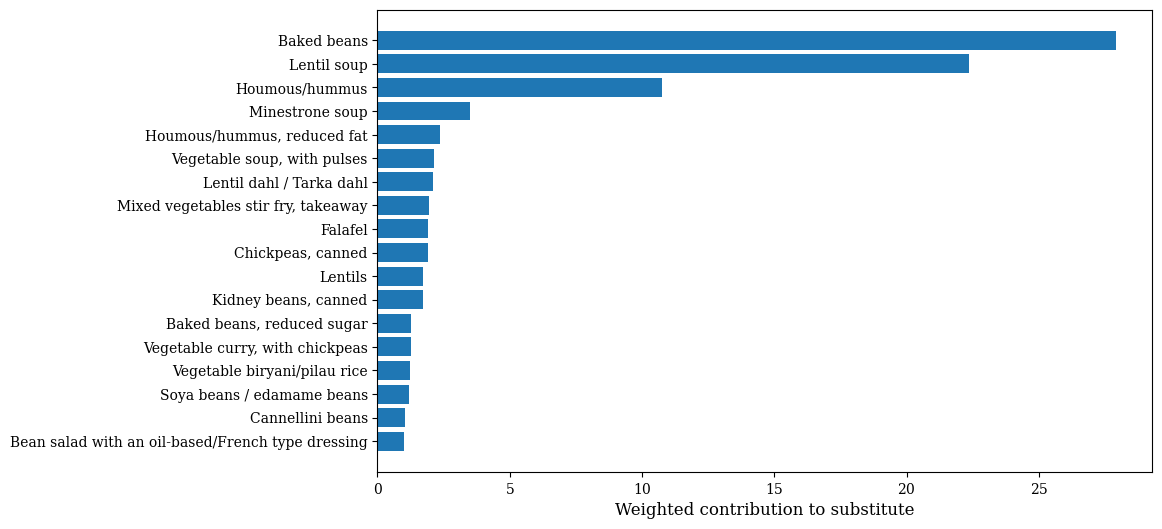

In [ ]:
dict_item_percent = daily_consumption_dict(item_list=bean_items_final, diet_data=diet_data)
pulse_dict_percent = {k: v for k, v in dict_item_percent.items() if v > 1}
top_items_pulse = sorted(pulse_dict_percent.items(), key=lambda x: x[1], reverse=True)

plt.figure(figsize=(10,6))

# Plot a histogram of the top items
labels, values = zip(*top_items_pulse)
labels = labels[::-1]
values = values[::-1]

plt.barh(labels, values)
plt.xlabel('Weighted contribution to substitute', fontsize = 12)
plt.savefig(plot_path / "pulse_sub.png", dpi=300,bbox_inches="tight")
plt.show()

Egg

In [ ]:
egg_items = ['Fried egg',
 'Poached egg',
 'Boiled egg',
  'Scrambled egg',
 'Boiled egg, white only',
  'Duck egg',
  'Egg, fried without fat',
  'Egg, fried in butter',
  'Boiled egg, yolk only',
   'Pickled egg']


In [ ]:
dairy_egg_items = diet_data[diet_data["FoodDescription"].isin(egg_items) & (diet_data[dairy_food_groups].any(axis=1) > 0)]['FoodDescription'].unique()

In [ ]:
dairy_egg_items

array(['Fried egg', 'Scrambled egg', 'Egg, fried in butter'], dtype=object)

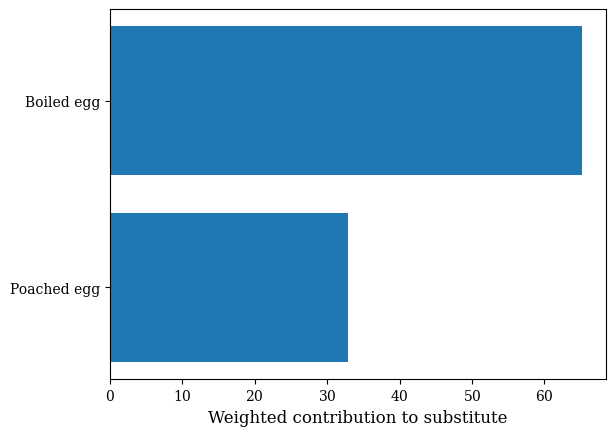

In [ ]:
egg_items = [item for item in egg_items if item not in set(dairy_egg_items)]
egg_dict_percent = daily_consumption_dict(item_list=egg_items, diet_data=diet_data)
egg_dict_percent = {k: v for k, v in egg_dict_percent.items() if v > 1}
top_items_egg = sorted(egg_dict_percent.items(), key=lambda x: x[1], reverse=True)

# Plot a histogram of the top items
labels, values = zip(*top_items_egg)
labels = labels[::-1]
values = values[::-1]

plt.barh(labels, values)

plt.xlabel('Weighted contribution to substitute', fontsize = 12)
plt.savefig(plot_path / "egg_sub.png", dpi=300,bbox_inches="tight")
plt.show()

In [ ]:
top_items_egg

[('Boiled egg', 65.24079781372009), ('Poached egg', 32.9047523181263)]

Plant-based milks

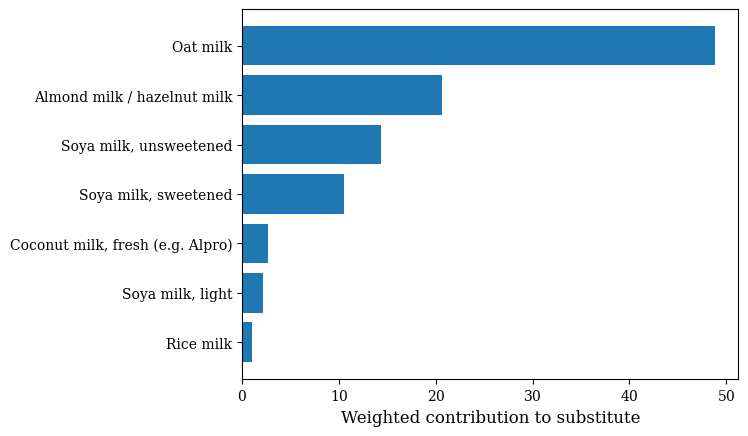

In [ ]:
plant_milks = ['Soya milk, unsweetened','Soya milk, light', 'Soya milk, sweetened',
               "Coconut milk, fresh (e.g. Alpro)",  "Oat milk", "Almond milk / hazelnut milk", "Rice milk"]

PB_milk_dict_percent = daily_consumption_dict(item_list=plant_milks, diet_data=diet_data)
PB_milk_dict_percent = {k: v for k, v in PB_milk_dict_percent.items() if v > 1}
top_PB_milk_items = sorted(PB_milk_dict_percent.items(), key=lambda x: x[1], reverse=True)

# Plot a histogram of the top items
labels, values = zip(*top_PB_milk_items)
labels = labels[::-1]
values = values[::-1]

plt.barh(labels, values)
plt.xlabel('Weighted contribution to substitute', fontsize = 12)
plt.savefig(plot_path / "PB_milk_sub.png", dpi=300,bbox_inches="tight")
plt.show()



Oily fish

In [ ]:
oilyfish_only, mixed_oilyfish = unique_mixed_items(variable='OilyFishg', diet_data=diet_data)

In [ ]:
oilyfish_only

['Salmon, steamed',
 'Sardine fillet, in oil, canned',
 'Sardine fillet, in brine, canned',
 'Salmon, cold smoked',
 'Kipper',
 'Trout, rainbow/brown',
 'Salmon, grilled or oven baked',
 'Sardine, grilled or oven baked',
 'Mackerel, grilled or oven baked',
 'Swordfish',
 'Mackerel fillet, in oil, canned']

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(oilyfish_only + mixed_oilyfish)])/len(diet_data)

0.004621976594047355

In [ ]:
smoked_items = []
total_oily_fish = oilyfish_only + mixed_oilyfish
for i in total_oily_fish:
  if 'smoked' in i.lower():
    smoked_items.append(i)

In [ ]:
smoked_items

['Salmon, cold smoked',
 'Mackerel, smoked',
 'Smoked salmon and cream cheese sandwich with white/malted bread',
 'Smoked salmon and cream cheese sandwich with wholemeal/oatmeal bread']

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(oilyfish_only)]) / len(diet_data[diet_data['FoodDescription'].isin(oilyfish_only + mixed_oilyfish)])

0.599644128113879

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(['Salmon, cold smoked',
 'Mackerel, smoked'])]) / len(diet_data[diet_data['FoodDescription'].isin(oilyfish_only)])

0.3798219584569733

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(oilyfish_only)])

337

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(oilyfish_only + mixed_oilyfish)])

562

In [ ]:
dairy_fish_items = diet_data[diet_data["FoodDescription"].isin(oilyfish_only + mixed_oilyfish) & (diet_data[dairy_food_groups].any(axis=1) > 0)]['FoodDescription'].unique()

In [ ]:
meat_fish_items = diet_data[diet_data["FoodDescription"].isin(oilyfish_only + mixed_oilyfish) & (diet_data[all_meat_food_groups].any(axis=1) > 0)]['FoodDescription'].unique()

In [ ]:
dairy_fish_items

array(['Fish/seafood quiche (e.g. salmon)', 'Salmon/tuna pate or mousse',
       'Smoked salmon and cream cheese sandwich with white/malted bread',
       'Pasta with seafood', 'Caesar salad dressing',
       'Fish/seafood chowder',
       'Smoked salmon and cream cheese sandwich with wholemeal/oatmeal bread',
       'Mackerel pate', 'Salmon fishcake', 'Salmon en croute',
       'Salmon in a watercress sauce'], dtype=object)

In [ ]:
meat_fish_items

array([], dtype=object)

In [ ]:
mixed_oilyfish

['Mackerel, smoked',
 'Mackerel fillet, in a tomato sauce, canned',
 'Fish/seafood quiche (e.g. salmon)',
 'Salmon/tuna pate or mousse',
 'Salmon, fried',
 'Herring, pickled',
 'Anchovies',
 'Salmon, canned',
 'Sushi, salmon based',
 'Smoked salmon and cream cheese sandwich with white/malted bread',
 'Sardine fillet, in a tomato sauce, canned',
 'Pasta with seafood',
 'Caesar salad dressing',
 'Salmon and cucumber sandwich with wholemeal/oatmeal bread',
 'Fish/seafood chowder',
 'Smoked salmon and cream cheese sandwich with wholemeal/oatmeal bread',
 'Mackerel pate',
 'Fish sandwich paste (e.g. salmon)',
 'Salmon fishcake',
 'Herring, fried',
 'Herring, in a tomato sauce, canned',
 'Salmon and cucumber sandwich with white/malted bread',
 'Salmon en croute',
 'Mackerel, fried',
 'Whitebait',
 'Salmon in a watercress sauce']

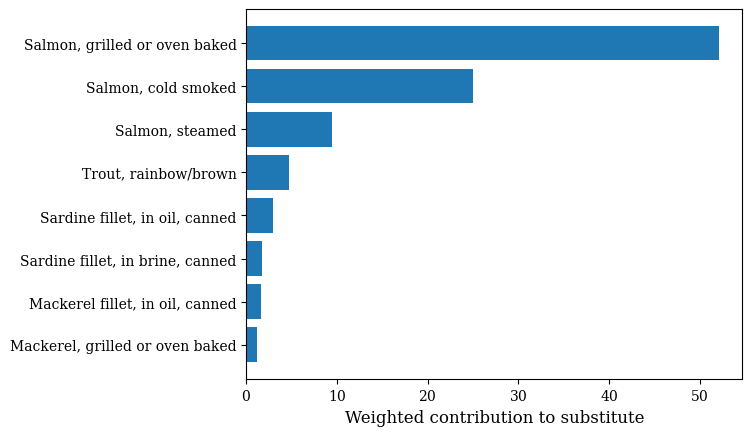

In [ ]:
# OF_items = pd.read_excel(data_path / 'substitute_items/OF_items.xlsx')
# OF_items = OF_items['Items'].tolist()
# OF_no_smoked = OF_items.copy()

# for item in OF_no_smoked:
#   if 'smoked' in item.lower():
#     OF_no_smoked.remove(item)

OF_items = [item for item in oilyfish_only if item not in set(dairy_fish_items)]

OF_dict_percent = daily_consumption_dict(item_list=OF_items, diet_data=diet_data)
OF_dict_percent = {k: v for k, v in OF_dict_percent.items() if v > 1}
top_OF_items = sorted(OF_dict_percent.items(), key=lambda x: x[1], reverse=True)

# Plot a histogram of the top items
labels, values = zip(*top_OF_items)
labels = labels[::-1]
values = values[::-1]

plt.barh(labels, values)
plt.xlabel('Weighted contribution to substitute', fontsize = 12)
plt.savefig(plot_path / "OF_sub.png", dpi=300,bbox_inches="tight")
plt.show()

In [ ]:
OF_items = [item for item in oilyfish_only + mixed_oilyfish if item not in set(dairy_fish_items)]
OF_dict_percent = daily_consumption_dict(item_list=OF_items, diet_data=diet_data)

In [ ]:
OF_dict_percent

{'Salmon, steamed': 7.0198091876725695,
 'Sardine fillet, in oil, canned': 2.228776818116147,
 'Sardine fillet, in brine, canned': 1.3096041274959105,
 'Salmon, cold smoked': 18.69475004809207,
 'Kipper': 0.4397682655277713,
 'Trout, rainbow/brown': 3.5034888565043594,
 'Salmon, grilled or oven baked': 38.93439449976162,
 'Sardine, grilled or oven baked': 0.1257782032646844,
 'Mackerel, grilled or oven baked': 0.897080847598906,
 'Swordfish': 0.32113664551735294,
 'Mackerel fillet, in oil, canned': 1.226398512225331,
 'Mackerel, smoked': 7.399361362130157,
 'Mackerel fillet, in a tomato sauce, canned': 1.8867263994936143,
 'Salmon, fried': 4.613225569567301,
 'Herring, pickled': 1.4736021902386334,
 'Anchovies': 1.3758004079543162,
 'Salmon, canned': 1.3645410549244652,
 'Sushi, salmon based': 3.5008058357044063,
 'Sardine fillet, in a tomato sauce, canned': 1.2261439218352785,
 'Salmon and cucumber sandwich with wholemeal/oatmeal bread': 0.6239462840993525,
 'Fish sandwich paste (e.g.

In [ ]:
calculate_proportion_non_composite(non_composite_list = oilyfish_only, proportional_dict=OF_dict_percent)

0.7470098601177674

In [ ]:
OF_items_all = [item for item in oilyfish_only + mixed_oilyfish if item not in set(list(meat_fish_items) + list(dairy_fish_items))]

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(oilyfish_only)]) / len(diet_data[diet_data['FoodDescription'].isin(OF_items_all)])

0.7139830508474576

Plant-based solid fats

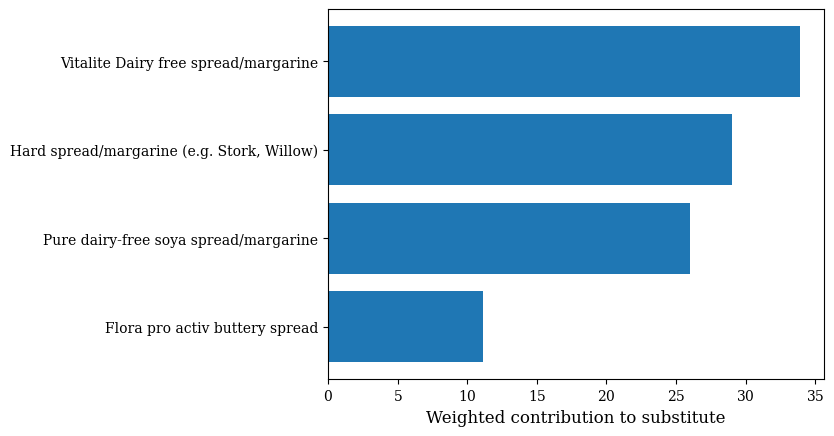

In [ ]:
PB_SF_items = ["Flora pro activ buttery spread", "Vitalite Dairy free spread/margarine", "Pure dairy-free soya spread/margarine", "Hard spread/margarine (e.g. Stork, Willow)" ]

PB_SF_dict_percent = daily_consumption_dict(item_list=PB_SF_items, diet_data=diet_data)
PB_SF_dict_percent = {k: v for k, v in PB_SF_dict_percent.items() if v > 1}
top_PB_SF_items = sorted(PB_SF_dict_percent.items(), key=lambda x: x[1], reverse=True)

# Plot a histogram of the top items
labels, values = zip(*top_PB_SF_items)
labels = labels[::-1]
values = values[::-1]

plt.barh(labels, values)

plt.xlabel('Weighted contribution to substitute', fontsize = 12)
#plt.xticks(rotation=90, fontsize=12)

plt.savefig(plot_path / "PB_SF_sub.png", dpi=300,bbox_inches="tight")
plt.show()

Poultry


In [ ]:
poultry_only, mixed_poultry = unique_mixed_items(variable='Poultryg', diet_data=diet_data)

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(poultry_only)])/len(diet_data[diet_data['FoodDescription'].isin(poultry_only + mixed_poultry)])

0.16473029045643153

In [ ]:
dairy_poultry_items = diet_data[diet_data["FoodDescription"].isin(poultry_only + mixed_poultry) & (diet_data[dairy_food_groups].any(axis=1) > 0)]['FoodDescription'].unique()

In [ ]:
all_meat_food_groups

['Beefg',
 'Lambg',
 'Porkg',
 'Burgersg',
 'OtherRedMeatg',
 'ProcessedRedMeatg',
 'Sausagesg',
 'Offalg',
 'Poultryg',
 'ProcessedPoultryg',
 'GameBirdsg']

In [ ]:
meat_food_groups_exclude = ['Beefg',
 'Lambg',
 'Porkg',
 'Burgersg',
 'OtherRedMeatg',
 'ProcessedRedMeatg',
 'Sausagesg',
 'Offalg',
 'ProcessedPoultryg',
 'GameBirdsg']

In [ ]:
meat_poultry_items = diet_data[diet_data["FoodDescription"].isin(poultry_only + mixed_poultry) & (diet_data[meat_food_groups_exclude].any(axis=1) > 0)]['FoodDescription'].unique()

In [ ]:
poultry_items = [item for item in poultry_only + mixed_poultry if item not in set(list(meat_poultry_items)+list(dairy_poultry_items))]
#

In [ ]:
poultry_dict_percent = daily_consumption_dict(item_list=poultry_items, diet_data=diet_data)
calculate_proportion_non_composite(non_composite_list = poultry_only, proportional_dict=poultry_dict_percent)

0.20212671594353157

In [ ]:
len(diet_data[diet_data['FoodDescription'].isin(poultry_only)])/len(diet_data[diet_data['FoodDescription'].isin(poultry_items)])

0.23574821852731592

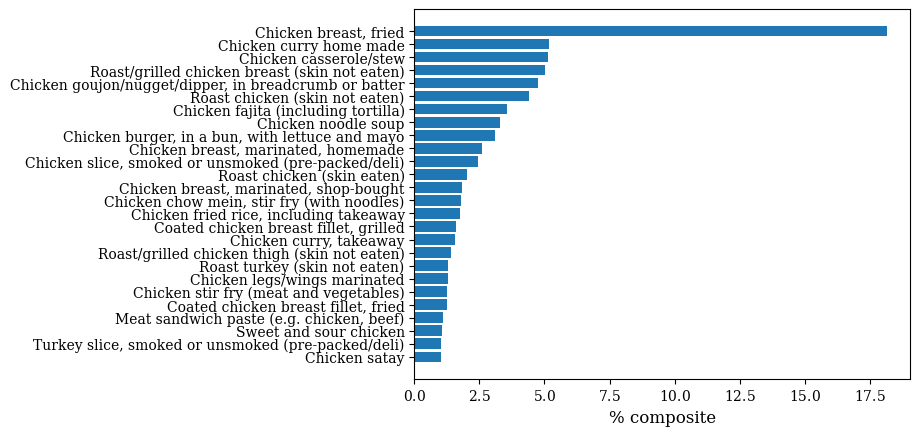

In [ ]:
poultry_dict_percent = daily_consumption_dict(item_list=poultry_items, diet_data=diet_data)
poultry_dict_percent = {k: v for k, v in poultry_dict_percent.items() if v > 1}
top_poultry_items = sorted(poultry_dict_percent.items(), key=lambda x: x[1], reverse=True)

# Plot a histogram of the top items
labels, values = zip(*top_poultry_items)
labels = labels[::-1]
values = values[::-1]

plt.barh(labels, values)

plt.xlabel('% composite', fontsize = 12)
#plt.xticks(rotation=90, fontsize=12)

plt.savefig(plot_path / "poultry_sub_composite.png", dpi=300,bbox_inches="tight")
plt.show()

In [ ]:
diet_data[diet_data["FoodDescription"].isin(poultry_only)][dairy_food_groups].sum()

,0
Milk_Skimmed,0.0000
Milk_SemiSkimmed,0.0000
Milk_Whole,0.0000
Cheese_Skimmed,0.0000
Cheese_SemiSkimmed,0.0000
Cheese_Whole,0.0000
Yogurt_Skimmed,0.0000
Yogurt_SemiSkimmed,0.0000
Yogurt_Whole,380.6736
Cream_SemiSkimmed,0.0000


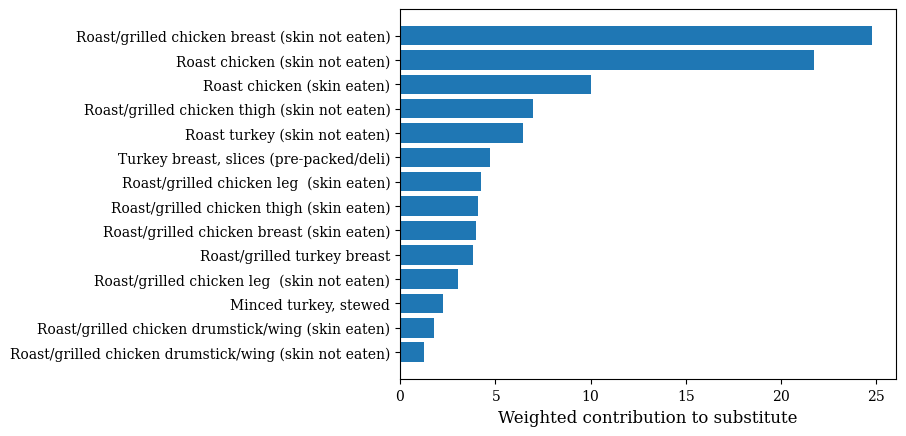

In [ ]:
poultry_only_items = [item for item in poultry_only if item not in set(list(meat_poultry_items)+list(dairy_poultry_items))]

poultry_dict_percent = daily_consumption_dict(item_list=poultry_only_items, diet_data=diet_data)
poultry_dict_percent = {k: v for k, v in poultry_dict_percent.items() if v > 1}
top_poultry_items = sorted(poultry_dict_percent.items(), key=lambda x: x[1], reverse=True)

# Plot a histogram of the top items
labels, values = zip(*top_poultry_items)
labels = labels[::-1]
values = values[::-1]

plt.barh(labels, values)

plt.xlabel('Weighted contribution to substitute', fontsize = 12)
#plt.xticks(rotation=90, fontsize=12)

plt.savefig(plot_path / "poultry_sub_non_composite.png", dpi=300,bbox_inches="tight")
plt.show()

In [ ]:
poultry_dict_percent

{'Roast/grilled chicken breast (skin not eaten)': 24.793086711619715,
 'Roast/grilled turkey breast': 3.8454907833266225,
 'Roast chicken (skin eaten)': 9.996697772057201,
 'Roast chicken (skin not eaten)': 21.70444334871941,
 'Roast/grilled chicken thigh (skin not eaten)': 6.985670693918948,
 'Turkey breast, slices (pre-packed/deli)': 4.7050695021825115,
 'Roast/grilled chicken breast (skin eaten)': 4.000073228651064,
 'Roast turkey (skin not eaten)': 6.454697666192579,
 'Roast/grilled chicken leg  (skin eaten)': 4.222270442204491,
 'Minced turkey, stewed': 2.2284314431248555,
 'Roast/grilled chicken drumstick/wing (skin eaten)': 1.7765857086236951,
 'Roast/grilled chicken drumstick/wing (skin not eaten)': 1.2679962259072475,
 'Roast/grilled chicken leg  (skin not eaten)': 3.0454172246051736,
 'Roast/grilled chicken thigh (skin eaten)': 4.114780256488326}

In [ ]:
total = 0
for val in poultry_dict_percent.values():
  total += val
print(total)


99.14071100762185


# Compute the nutrients per gram of all items in the weighted composite and the nutrients per gram of the weighted composite foods

In [ ]:
nutrients_per_gram_sub = pd.read_parquet(data_path / "nutrients_per_gram_sub.parquet")

In [ ]:
nutrients_per_gram_sub.loc['pulse average', "Beansg"]

np.float64(0.3890907587774904)

In [ ]:
substitute_proportions = {
"Vegetables": veg_dict_percent,
 "Pulses and legumes": pulse_dict_percent,
 "Plant-based meat alternatives": PB_dict_percent,
 "Egg": egg_dict_percent,
  "Oily fish": OF_dict_percent,
 "Poultry": poultry_dict_percent,
  "Plant-based milks": PB_milk_dict_percent,
 "Plant-based solid fats": PB_SF_dict_percent
}

In [ ]:
import openpyxl

In [ ]:
# Save the nutrient content of the substitutes to a spreadsheet (generated with Gemini 3.1 Pro)
output_path = plot_path / 'food_substitutes.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:

  # Loop through each item in your main dictionary
  for sheet_name, data_dict in substitute_proportions.items():

      print(f"Processing sheet: {sheet_name}...")

      # This list will hold the data for the new DataFrame
      sheet_data_rows = []

      # Loop through the inner dictionary (e.g., OF_dict_percent)
      for item, contribution in data_dict.items():

          contribution = np.round(contribution, 2)

          # --- Look up the Food Code ---
          try:
              # Use your provided logic to find the food code
              food_code = diet_data[diet_data['FoodDescription'] == item]['FoodNumber'].iloc[0]
          except IndexError:
              # Handle cases where the food item is not in diet_data
              food_code = 'Not Found'

          # Add the row data
          sheet_data_rows.append({
              "Food description, SHeS 2021": item,
              "Food code, SHeS 2021": food_code,
              "Relative contribution to composite replacement": contribution
          })

      # --- Create and Write DataFrame ---

      # Convert the list of dicts into a DataFrame
      df_sheet = pd.DataFrame(sheet_data_rows)

      # Write the DataFrame to the Excel file, on its own sheet
      # index=False prevents pandas from writing the DataFrame index (0, 1, 2...)
      df_sheet.to_excel(writer, sheet_name=sheet_name, index=False)

      # --- Adjust Column Widths ---

      # Get the openpyxl worksheet object
      worksheet = writer.sheets[sheet_name]

      # Iterate through all columns in the worksheet
      for column in worksheet.columns:
          max_length = 0
          column_letter = column[0].column_letter # Get column letter (e.g., 'A', 'B')

          # Find the longest cell value in the column
          for cell in column:
              try:
                  # Check length of cell value as a string
                  if len(str(cell.value)) > max_length:
                      max_length = len(str(cell.value))
              except:
                  pass # Ignore any errors

          # Set the column width (add a little padding)
          adjusted_width = (max_length + 2)
          worksheet.column_dimensions[column_letter].width = adjusted_width


Processing sheet: Vegetabes...
Processing sheet: Pulses and legumes...
Processing sheet: Plant-based meat alternatives...
Processing sheet: Egg...
Processing sheet: Oily fish...
Processing sheet: Poultry...
Processing sheet: Plant-based milks...
Processing sheet: Plant-based solid fats...


In [ ]:
OF_dict_percent

{'Salmon, steamed': 9.397210883623258,
 'Sardine fillet, in oil, canned': 2.9835975896821183,
 'Sardine fillet, in brine, canned': 1.7531283017997237,
 'Salmon, cold smoked': 25.02610881889138,
 'Trout, rainbow/brown': 4.690016884050271,
 'Salmon, grilled or oven baked': 52.12032207128237,
 'Mackerel, grilled or oven baked': 1.200895591200737,
 'Mackerel fillet, in oil, canned': 1.641743406214193}

In [ ]:
nutrients_per_gram_sub = item_only_nutrients(item_only=beans_only, nutrients=all_indicators, diet_data=diet_data)

for item in [brass_only, yrg_only, tomatoes_only, otherveg_only]:
  df_new = item_only_nutrients(item_only=item, nutrients=all_indicators, diet_data=diet_data)
  nutrients_per_gram_sub = pd.concat([nutrients_per_gram_sub, df_new], ignore_index=False)

In [ ]:
nutrients_per_gram_sub = add_weighted_composite(description = 'PB alt average',
                                                nutrients_per_gram_sub=nutrients_per_gram_sub,
                                                diet_data=diet_data,
                                                replacement_dict_weights=PB_dict_percent,
                                                indicators = all_indicators,
                                                error_columns = error_columns)

nutrients_per_gram_sub = add_weighted_composite(description = 'veg average',
                                                nutrients_per_gram_sub=nutrients_per_gram_sub,
                                                diet_data=diet_data,
                                                replacement_dict_weights=veg_dict_percent,
                                                indicators = all_indicators,
                                                error_columns = error_columns)

nutrients_per_gram_sub = add_weighted_composite(description = 'pulse average',
                                                nutrients_per_gram_sub=nutrients_per_gram_sub,
                                                diet_data=diet_data,
                                                replacement_dict_weights=pulse_dict_percent,
                                                indicators = all_indicators,
                                                error_columns = error_columns)

nutrients_per_gram_sub = add_weighted_composite(description = 'egg average',
                                                nutrients_per_gram_sub=nutrients_per_gram_sub,
                                                diet_data=diet_data,
                                                replacement_dict_weights=egg_dict_percent,
                                                indicators = all_indicators,
                                                error_columns = error_columns)

nutrients_per_gram_sub = add_weighted_composite(description = 'OF average',
                                                nutrients_per_gram_sub=nutrients_per_gram_sub,
                                                diet_data=diet_data,
                                                replacement_dict_weights=OF_dict_percent,
                                                indicators = all_indicators,
                                                error_columns = error_columns)

nutrients_per_gram_sub = add_weighted_composite(description = 'poultry average',
                                                nutrients_per_gram_sub=nutrients_per_gram_sub,
                                                diet_data=diet_data,
                                                replacement_dict_weights=poultry_dict_percent,
                                                indicators = all_indicators,
                                                error_columns = error_columns)

nutrients_per_gram_sub = add_weighted_composite(description = 'PB milk average',
                                                nutrients_per_gram_sub=nutrients_per_gram_sub,
                                                diet_data=diet_data,
                                                replacement_dict_weights=PB_milk_dict_percent,
                                                indicators = all_indicators,
                                                error_columns = error_columns)

nutrients_per_gram_sub = add_weighted_composite(description = 'PB SF average',
                                                nutrients_per_gram_sub=nutrients_per_gram_sub,
                                                diet_data=diet_data,
                                                replacement_dict_weights=PB_SF_dict_percent,
                                                indicators = all_indicators,
                                                error_columns = error_columns
                                                )

Include the poultry and plant-based yoghurt replacement which are considered as single item substitutions

In [ ]:
for item in ["Roast/grilled chicken breast (skin not eaten)", 'Soya yoghurt, plain (e.g. Alpro Soya)']:
  item_consumption = diet_data[diet_data['FoodDescription'] == item][all_indicators]
  nutr_per_gram = item_consumption.div(item_consumption['TotalGrams'], axis=0)
  nutrients_per_gram_sub.loc[item] = nutr_per_gram.mean()

In [ ]:
# save the dataframe
nutrients_per_gram_sub.to_parquet(data_path / "nutrients_per_gram_sub.parquet")

In [ ]:
nutrients_example  = ['Energykcal', "Proteing", "Calciummg", "Zincmg", "FreeSugarsg", 'median_GHG', 'median_price_sim']

In [ ]:
comp_dict = {
"Vegetables": 'veg average',
 "Pulses and legumes": 'pulse average',
 "Plant-based meat alternatives": 'PB alt average',
 "Egg": 'egg average',
  "Oily fish": 'OF average',
 "Poultry": 'poultry average',
  "Plant-based milks": 'PB milk average',
 "Plant-based solid fats": 'PB SF average'
}

In [ ]:
def nutrient_per_gram_table(consumption_dict: dict, food_group: str, composite_item: str):

  food_group_df = nutrients_per_gram_sub.loc[list(consumption_dict.keys())][nutrients_example].copy()
  food_group_df.loc[consumption_dict.keys(), 'Consumption frequency, %'] = pd.Series(consumption_dict)
  food_group_df = np.round(food_group_df, 3)

  food_group_df.loc[f'{food_group} composite', nutrients_example] = nutrients_per_gram_sub.loc[composite_item, nutrients_example]
  food_group_df.loc[f'{food_group} composite', nutrients_example] = np.round(food_group_df.loc[f'{food_group} composite', nutrients_example], 2)

  food_group_df.to_excel(f"results/Tables/food_group_df_{food_group}.xlsx")

  return

In [ ]:
for food_group, composite_item in comp_dict.items():
  consumption_dict = substitute_proportions[food_group]
  nutrient_per_gram_table(consumption_dict=consumption_dict, food_group=food_group, composite_item=composite_item)

In [ ]:
food_group_df = nutrients_per_gram_sub.loc[list(pulse_dict_percent.keys())][nutrients_example].copy()

In [ ]:
food_group_df.loc[pulse_dict_percent.keys(), 'Consumption frequency, %'] = pd.Series(pulse_dict_percent)

In [ ]:
food_group_df = np.round(food_group_df, 3)

In [ ]:
food_group_df.loc['Vegetable composite', nutrients_example] = nutrients_per_gram_sub.loc['veg average', nutrients_example]
food_group_df.loc['Vegetable composite', nutrients_example] = np.round(food_group_df.loc['Vegetable composite', nutrients_example], 2)

In [ ]:
food_group_df.loc['Vegetable composite', nutrients_example]

In [ ]:
food_group_df.to_excel("results/Tables/food_group_df_veg.xlsx")

In [ ]:
nutrients_per_gram_sub = add_weighted_composite(description = 'veg average all',
                                                nutrients_per_gram_sub=nutrients_per_gram_sub,
                                                diet_data=diet_data,
                                                replacement_dict_weights=veg_dict_percent_all,
                                                indicators = all_indicators,
                                                error_columns = error_columns)